## Part 0. 환경 구축

### 0-1. Miniconda 설치

1. https://docs.anaconda.com/miniconda/ 에서 본인 OS에 맞는 설치 파일 다운로드
2. 설치 완료 후 터미널(Mac/Linux) 또는 **Anaconda Prompt**(Windows)에서 확인:

```
conda --version
```

### 0-2. 가상환경 생성 및 활성화

```
conda create -n vip python=3.13 -y
conda activate vip
```

> 실습 전 매번 `conda activate vip` 실행 필요

### 0-3. 라이브러리 설치

```
pip install numpy opencv-python matplotlib jupyter
```

| 패키지 | 역할 |
|--------|------|
| `numpy` | 행렬 연산 |
| `opencv-python` | 영상 처리 (OpenCV) |
| `matplotlib` | 시각화 |
| `jupyter` | Notebook 환경 |

### 0-4. Jupyter Notebook 실행

```
jupyter notebook
```

- 브라우저가 열리면 **New → Python 3** 또는 이 `.ipynb` 파일 열기
- 셀 실행: **Shift + Enter**

## Part 1. 이미지 로드와 구조 확인

### 1-1. 라이브러리 import

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

### 1-2. 이미지 읽기

In [2]:
img = cv2.imread('pi.jpg')

if img is None:
    print("이미지를 찾을 수 없습니다. 파일 경로를 확인하세요.")
else:
    print("이미지 로드 성공")

이미지 로드 성공


### 1-3. type / shape / dtype 확인

In [3]:
# ── 이미지의 정체 ──
print(f"type  : {type(img)}")    # numpy.ndarray — 이미지는 숫자 배열
print(f"shape : {img.shape}")     # (H, W, 3) — 세로, 가로, 채널 수
print(f"dtype : {img.dtype}")     # uint8 — 부호없는 8비트 정수 (0~255)

type  : <class 'numpy.ndarray'>
shape : (238, 330, 3)
dtype : uint8


### 1-4. 픽셀 하나 꺼내보기

In [4]:
# ── 특정 좌표의 픽셀값 확인 ──
# img[행, 열] = img[y, x] — 행(세로)이 먼저, 열(가로)이 나중
pixel = img[100, 200]

print(f"img[100, 200] = {pixel}")
print(f"  B={pixel[0]}, G={pixel[1]}, R={pixel[2]}")
print()
print("※ OpenCV는 BGR 순서로 저장한다 (RGB가 아님)")

img[100, 200] = [ 64 197 235]
  B=64, G=197, R=235

※ OpenCV는 BGR 순서로 저장한다 (RGB가 아님)


### 1-5. 이미지 시각화 — BGR vs RGB

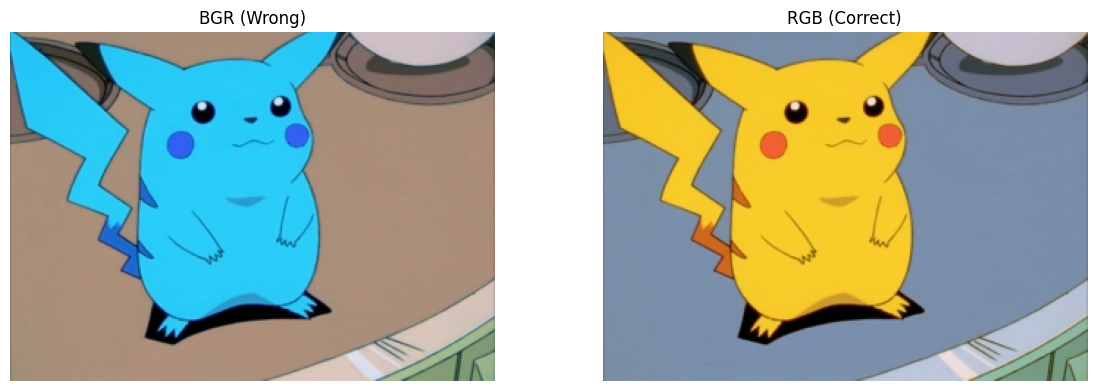

In [7]:
# ── matplotlib은 RGB를 기대하므로, BGR 그대로 넘기면 색이 뒤집힌다 ──
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB 변환

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)          # BGR 그대로 — 색이 이상하게 보임
plt.title('BGR (Wrong)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_rgb)      # RGB 변환 후 — 정상
plt.title('RGB (Correct)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Part 2. 색 공간 변환과 채널 분리

### 2-1. 그레이스케일 변환

In [5]:
# ── 컬러 → 흑백 ──
# 내부적으로 0.299*R + 0.587*G + 0.114*B 가중 평균 적용
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print(f"컬러  shape: {img.shape}")    # (H, W, 3)
print(f"흑백  shape: {gray.shape}")   # (H, W) — 채널 축 소멸

컬러  shape: (238, 330, 3)
흑백  shape: (238, 330)


$$Gray = 0.299R + 0.587G + 0.114B$$

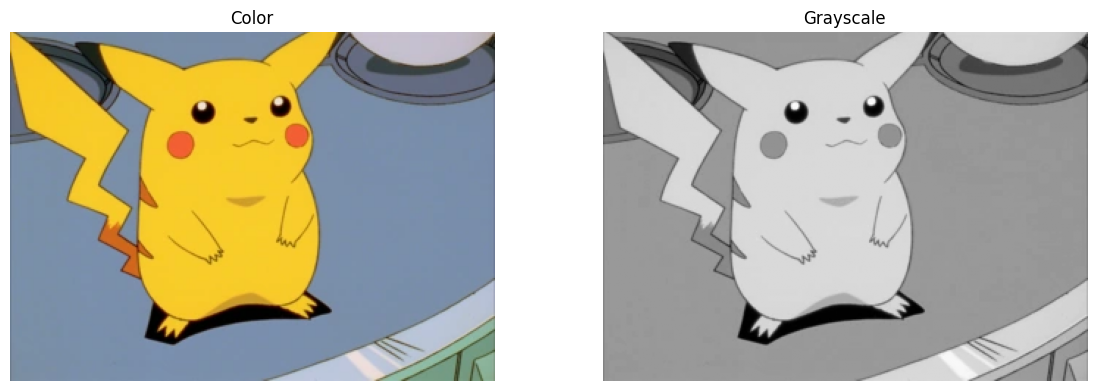

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Color')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap='gray')  # 단일 채널은 cmap='gray' 필수
plt.title('Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

### 2-2. HSV 변환

In [9]:
# ── BGR → HSV ──
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

print(f"BGR shape: {img.shape}")
print(f"HSV shape: {img_hsv.shape}")  # 크기 동일 — 숫자의 '의미'만 바뀜
print()
print("OpenCV HSV 범위:")
print("  H: 0~180 (360도를 2로 나눔)")
print("  S: 0~255")
print("  V: 0~255")

BGR shape: (238, 330, 3)
HSV shape: (238, 330, 3)

OpenCV HSV 범위:
  H: 0~180 (360도를 2로 나눔)
  S: 0~255
  V: 0~255


### 2-3. 채널 분리 (cv2.split)

In [10]:
# ── 3D 텐서(H,W,3)를 2D 행렬(H,W) 3장으로 분리 ──
h_ch, s_ch, v_ch = cv2.split(img_hsv)

print(f"HSV 텐서 shape : {img_hsv.shape}")  # (H, W, 3)
print(f"H 채널 shape   : {h_ch.shape}")      # (H, W)
print(f"S 채널 shape   : {s_ch.shape}")
print(f"V 채널 shape   : {v_ch.shape}")

HSV 텐서 shape : (238, 330, 3)
H 채널 shape   : (238, 330)
S 채널 shape   : (238, 330)
V 채널 shape   : (238, 330)


### 2-4. 채널별 시각화

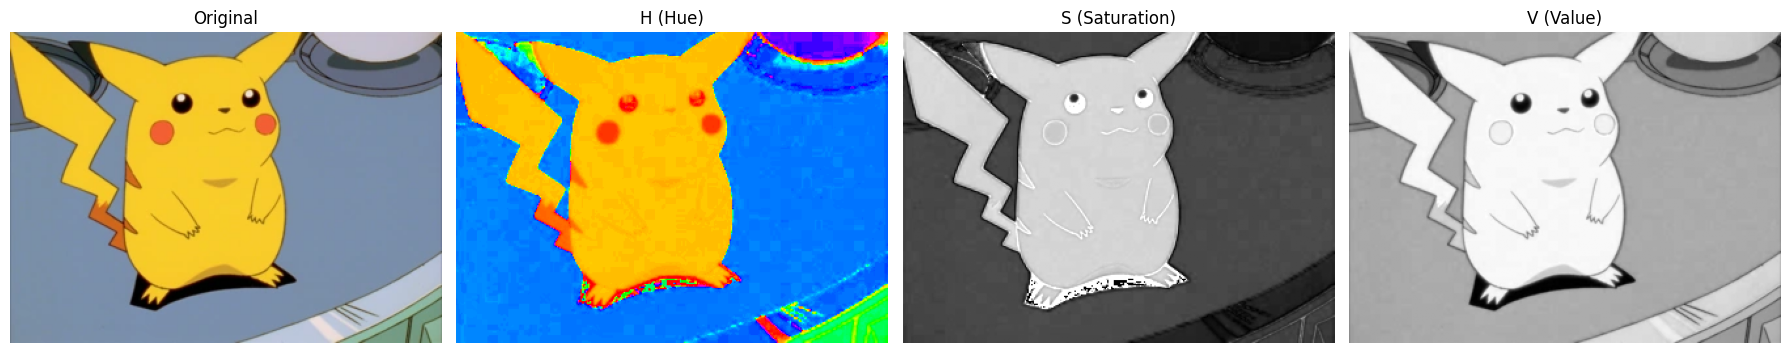

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(img_rgb)
axes[0].set_title('Original')

axes[1].imshow(h_ch, cmap='hsv', vmin=0, vmax=180)
axes[1].set_title('H (Hue)')

axes[2].imshow(s_ch, cmap='gray')
axes[2].set_title('S (Saturation)')

axes[3].imshow(v_ch, cmap='gray')
axes[3].set_title('V (Value)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Part 3. 점 연산 (Point Operation)

### 3-1. 밝기 조절: 덧셈

$$g = f + k$$

In [12]:
# ── uint8 오버플로 시연 ──
# uint8 끼리 더하면 255를 넘는 값이 0부터 다시 돌아간다

bright_overflow = gray + np.uint8(80)

print(f"원본 최대값:        {gray.max()}")
print(f"+80 후 최대값:      {bright_overflow.max()}")
print(f"→ {int(gray.max())} + 80 = {int(gray.max()) + 80} 이지만 uint8 범위 초과 → 오버플로 발생")

원본 최대값:        234
+80 후 최대값:      255
→ 234 + 80 = 314 이지만 uint8 범위 초과 → 오버플로 발생


In [13]:
# ── 안전한 방법: 타입 확장 → 연산 → 클리핑 → 복원 ──

# int16으로 확장 (-32768 ~ 32767)
temp = gray.astype(np.int16) + 80

# 0~255 범위 벗어난 값을 잘라냄
temp = np.clip(temp, 0, 255)

# uint8로 복원
bright_safe = temp.astype(np.uint8)

# 어둡게도 같은 방식
dark_safe = np.clip(gray.astype(np.int16) - 80, 0, 255).astype(np.uint8)

print(f"클리핑 후 최대값: {bright_safe.max()}")

클리핑 후 최대값: 255


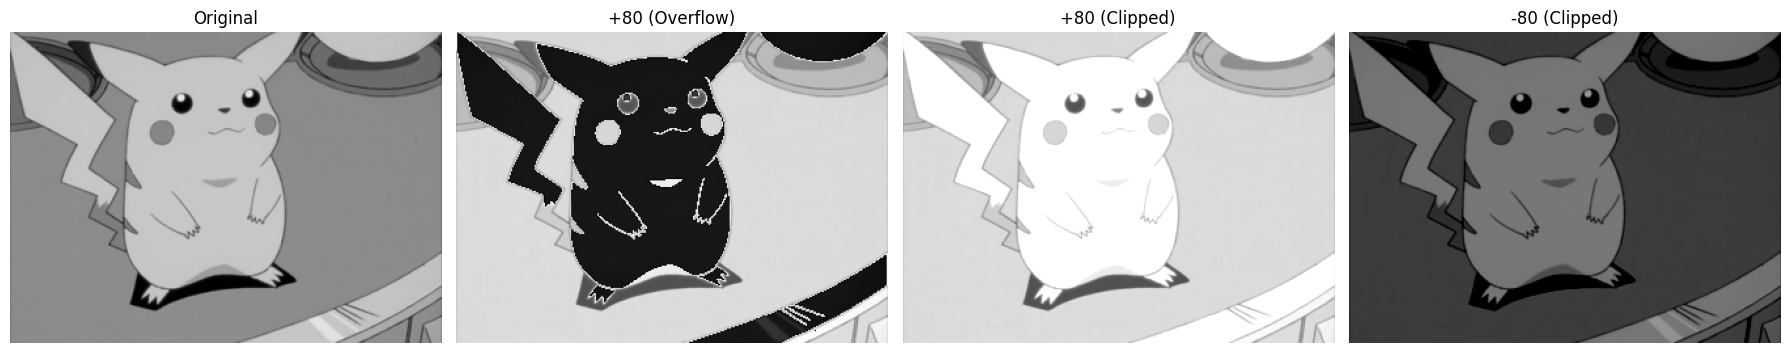

In [14]:
# ── 오버플로 vs 클리핑 비교 ──
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, im, t in zip(axes,
    [gray, bright_overflow, bright_safe, dark_safe],
    ['Original', '+80 (Overflow)', '+80 (Clipped)', '-80 (Clipped)']):
    ax.imshow(im, cmap='gray', vmin=0, vmax=255)
    ax.set_title(t)
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3-2. 대비 조절: 곱셈

$$g = \alpha \cdot f + \beta$$

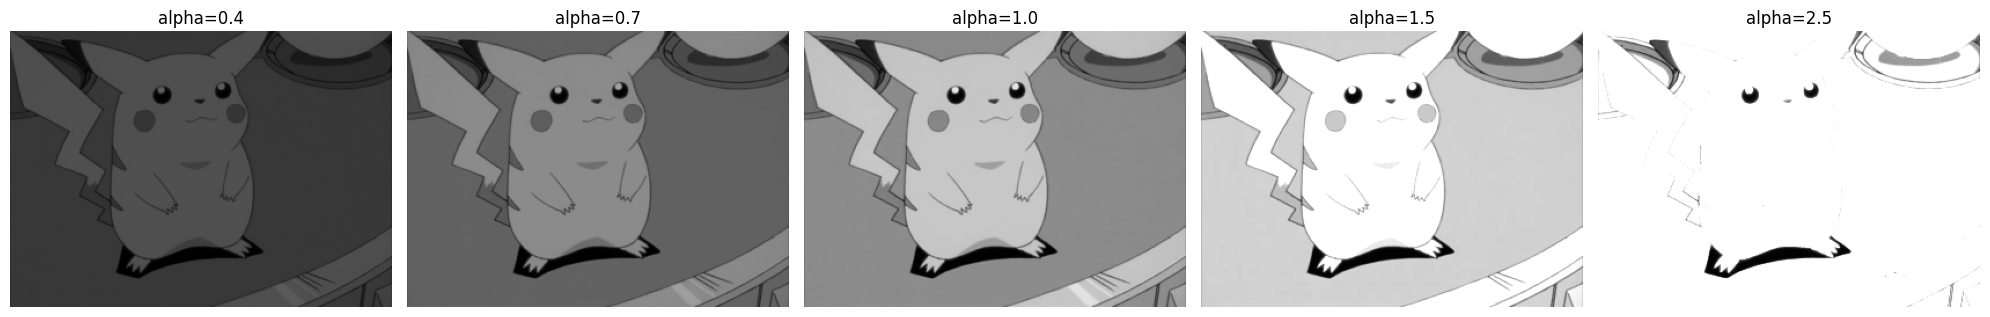

In [15]:
# ── g = alpha * f + beta ──
# alpha > 1: 대비 증가 / alpha < 1: 대비 감소
# cv2.convertScaleAbs: alpha*f + beta 계산 + 클리핑 + uint8 변환 한번에

alphas = [0.4, 0.7, 1.0, 1.5, 2.5]

fig, axes = plt.subplots(1, len(alphas), figsize=(20, 4))

for ax, a in zip(axes, alphas):
    result = cv2.convertScaleAbs(gray, alpha=a, beta=0)
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'alpha={a}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3-3. 반전

$$g = 255 - f$$

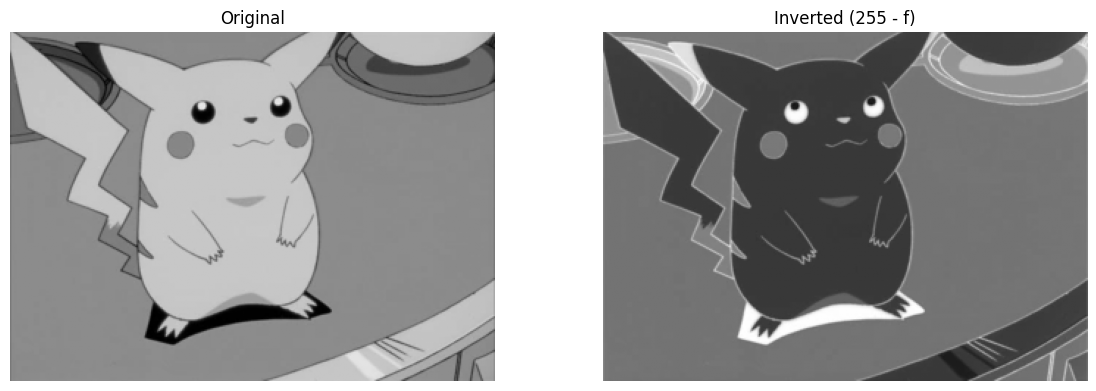

In [16]:
# ── g = 255 - f ──
inverted = 255 - gray

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(inverted, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Inverted (255 - f)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 3-4. 감마 보정

$$g = 255 \cdot \left(\frac{f}{255}\right)^{\gamma}$$

In [17]:
# ── g = 255 * (f / 255) ^ gamma ──
# gamma < 1: 어두운 영역 밝아짐
# gamma = 1: 변화 없음
# gamma > 1: 어두운 영역 더 어두워짐

def gamma_correction(image, gamma):
    """감마 보정 함수."""
    normalized = image.astype(np.float64) / 255.0   # 0~1 정규화
    corrected  = np.power(normalized, gamma)          # 감마 거듭제곱
    return (corrected * 255).astype(np.uint8)         # 0~255 복원

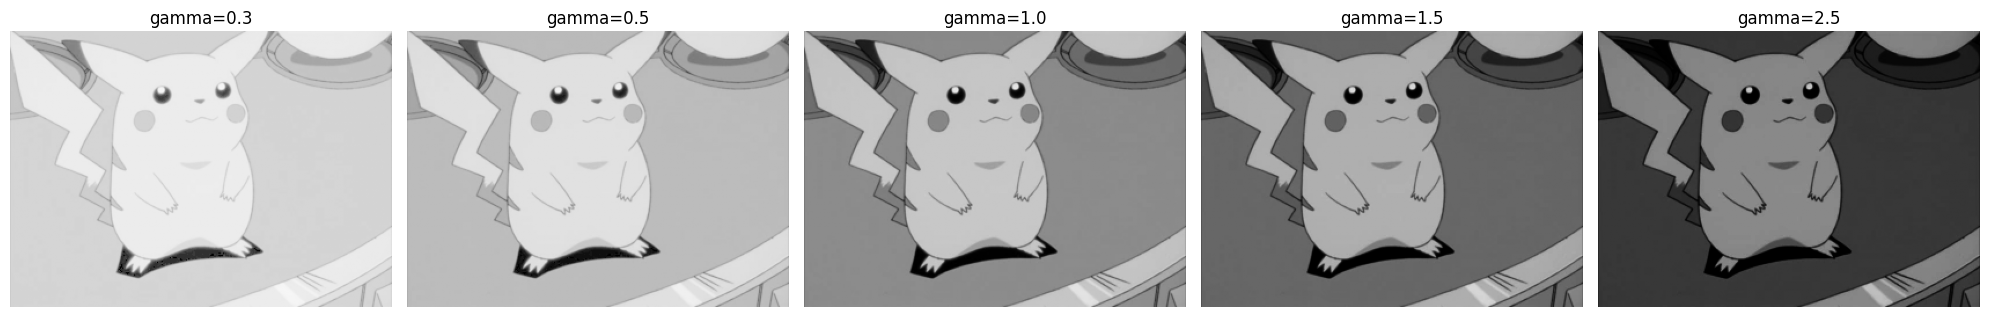

In [18]:
# ── 감마 값에 따른 변화 비교 ──
gammas = [0.3, 0.5, 1.0, 1.5, 2.5]

fig, axes = plt.subplots(1, len(gammas), figsize=(20, 4))

for ax, g in zip(axes, gammas):
    result = gamma_correction(gray, g)
    ax.imshow(result, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'gamma={g}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 3-5. 히스토그램 — 점 연산 효과 관찰

In [19]:
# ── 히스토그램 시각화 함수 ──

def show_with_hist(images, titles):
    """이미지와 히스토그램을 위아래로 배치."""
    n = len(images)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 6))
    if n == 1:
        axes = axes.reshape(2, 1)

    for i in range(n):
        # 이미지
        axes[0, i].imshow(images[i], cmap='gray', vmin=0, vmax=255)
        axes[0, i].set_title(titles[i])
        axes[0, i].axis('off')

        # 히스토그램
        # calcHist 인자: [이미지], [채널], 마스크, [bin수], [값 범위]
        hist = cv2.calcHist([images[i]], [0], None, [256], [0, 256])
        axes[1, i].fill_between(range(256), hist.ravel(),
                                color='steelblue', alpha=0.7)
        axes[1, i].set_xlim([0, 255])
        axes[1, i].set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

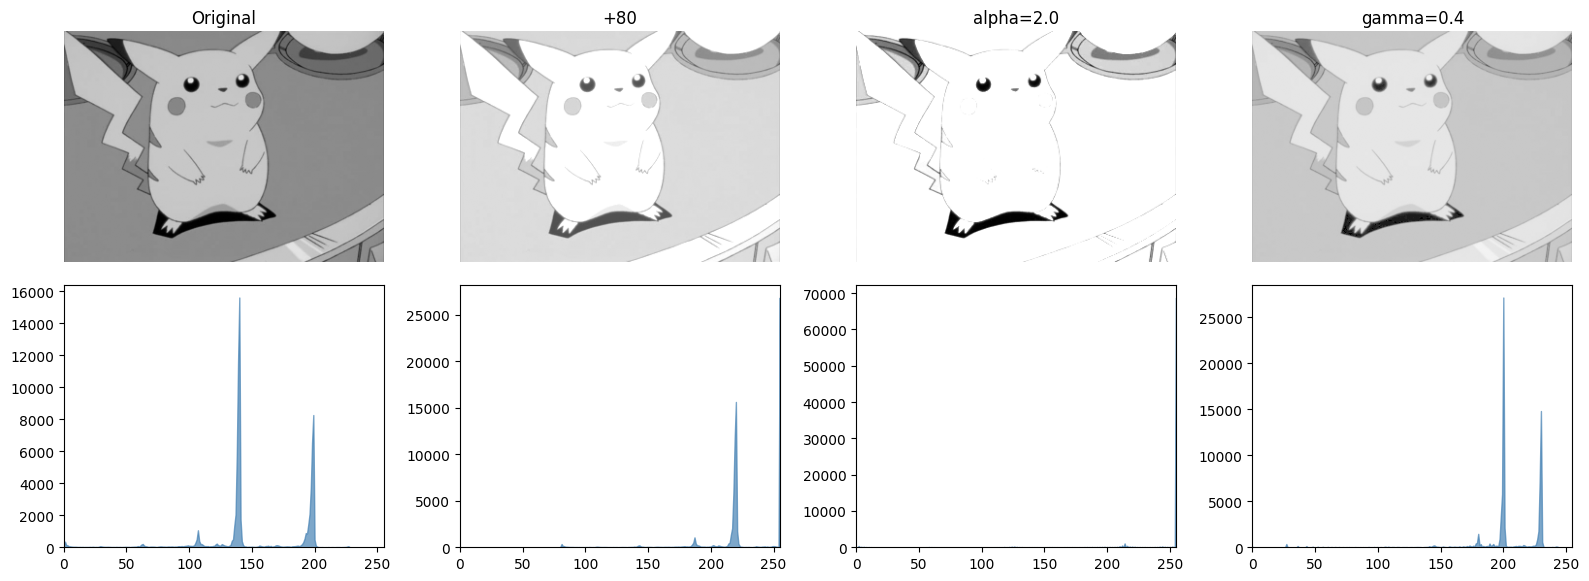

In [20]:
# ── 점 연산 전후 히스토그램 비교 ──
show_with_hist(
    [gray,
     np.clip(gray.astype(np.int16) + 80, 0, 255).astype(np.uint8),
     cv2.convertScaleAbs(gray, alpha=2.0, beta=0),
     gamma_correction(gray, 0.4)],
    ['Original', '+80', 'alpha=2.0', 'gamma=0.4']
)

---
## Part 4. HSV V채널 비파괴 보정 (5단계 파이프라인)

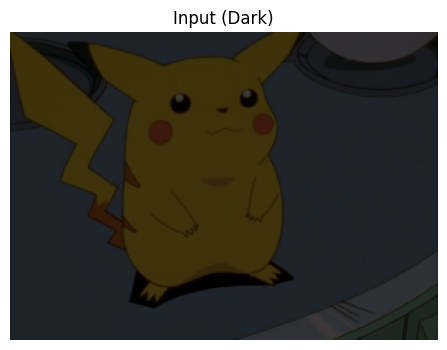

In [21]:
# ── 어두운 컬러 이미지 준비 ──
dark_color = cv2.convertScaleAbs(img, alpha=0.25, beta=0)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(dark_color, cv2.COLOR_BGR2RGB))
plt.title('Input (Dark)')
plt.axis('off')
plt.show()

In [22]:
# ============================================
#  5단계 파이프라인
# ============================================

# 1단계: 색 공간 변환 (BGR → HSV)
dark_hsv = cv2.cvtColor(dark_color, cv2.COLOR_BGR2HSV)

# 2단계: 채널 분리
h, s, v = cv2.split(dark_hsv)

# 3단계: V채널에만 감마 보정
v_corrected = gamma_correction(v, 0.4)

# 4단계: 채널 합성 (원본 H, S + 보정된 V)
corrected_hsv = cv2.merge([h, s, v_corrected])

# 5단계: 역변환 (HSV → BGR)
result_bgr = cv2.cvtColor(corrected_hsv, cv2.COLOR_HSV2BGR)

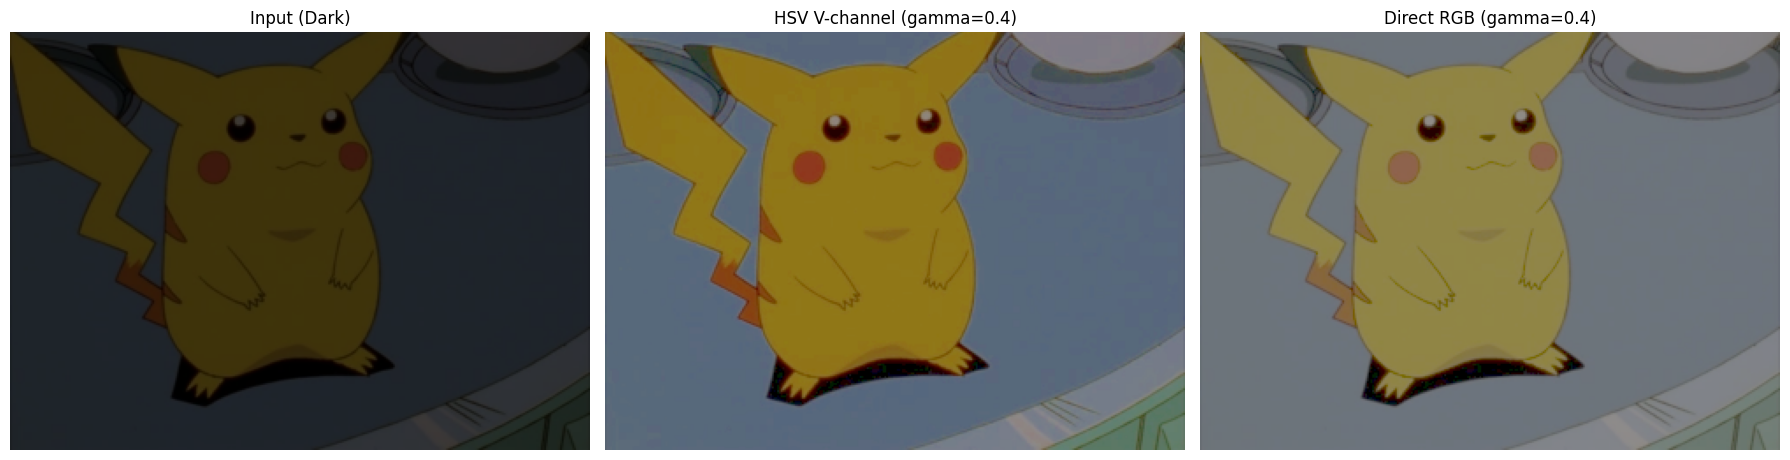

In [23]:
# ── 결과 비교: HSV V채널 보정 vs RGB 직접 보정 ──
result_direct = gamma_correction(dark_color, 0.4)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(cv2.cvtColor(dark_color, cv2.COLOR_BGR2RGB))
axes[0].set_title('Input (Dark)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(result_bgr, cv2.COLOR_BGR2RGB))
axes[1].set_title('HSV V-channel (gamma=0.4)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(result_direct, cv2.COLOR_BGR2RGB))
axes[2].set_title('Direct RGB (gamma=0.4)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

---
## 정리

| 연산 | 수식 | 효과 |
|------|------|------|
| 밝기 | `g = f + k` | 전체 밝기 이동 |
| 대비 | `g = α·f + β` | 명암비 확대/축소 |
| 반전 | `g = 255 - f` | 흑백 교환 |
| 감마 | `g = 255·(f/255)^γ` | 비선형 톤 매핑 |

- **uint8 오버플로 주의** → `astype(int16)` → 연산 → `np.clip` → `astype(uint8)`
- **히스토그램**으로 클리핑·편향 확인
- **비파괴 보정**: HSV에서 V채널만 건드리면 색상 보존